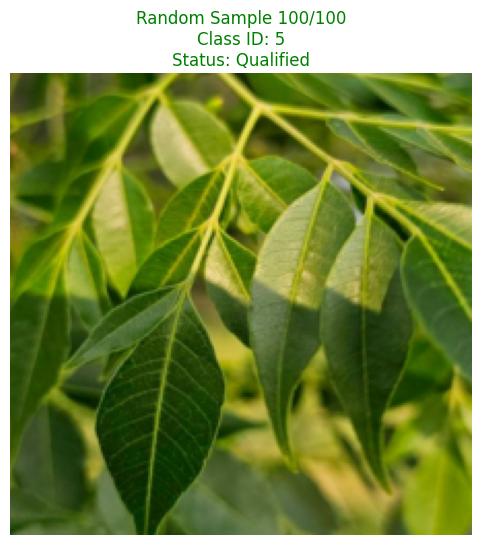

Index: 75789
Class Name: 苦棟
Status: Qualified
Validation Finished.


In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
%matplotlib inline
import time
import random
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import sys
import os
import torch

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
  sys.path.append(root_path)

from src.PlantLazyDataset import PlantLazyDataset
from config.MyConfig import MyConfig

def verify_dataset_logic(dataset, num_samples=10, delay=2.0):
    """
    從所有類別中隨機抽樣驗證，已移除 plt.title 中的中文字元以避免字體警告
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    total_len = len(dataset)
    
    for i in range(num_samples):
        random_idx = random.randint(0, total_len - 1)
        image_tensor, label, is_qualified = dataset[random_idx]
        
        img_to_show = image_tensor.permute(1, 2, 0).numpy()
        
        clear_output(wait=True)
        
        # 取得類別資訊與狀態
        class_name = dataset.class_names[label.item()]
        status_str = "Qualified" if is_qualified else "Unqualified (Fallback)"
        status_color = "green" if is_qualified else "red"
        
        plt.imshow(img_to_show)
        # 標題僅保留英文與索引，避開 CJK 字元
        plt.title(f"Random Sample {i+1}/{num_samples}\nClass ID: {label.item()}\nStatus: {status_str}", 
                  color=status_color, fontsize=12)
        plt.axis('off')
        display(plt.gcf())
        
        # 中文資訊由 print 輸出，這部分在 Notebook 中顯示是正常的
        print(f"Index: {random_idx}")
        print(f"Class Name: {class_name}") 
        print(f"Status: {status_str}")
        
        time.sleep(delay)
    
    plt.close()
    print("Validation Finished.")

# --- Execution ---

config = MyConfig()

dataset = PlantLazyDataset(
  root_dir=config.raw_data_dirs[0], 
  target_size=config.img_size,
  samples_per_image=50,
  green_threshold=0.2
)

print(f"Dataset loaded. Classes: {dataset.class_names}")
print(f"Total virtual samples: {len(dataset)}")

print("-" * 30)

# 單張測試
test_idx = random.randint(0, len(dataset) - 1)
img_tensor, label, is_qualified = dataset[test_idx]

#print(f"Single Random Test (Index {test_idx}):")
#print(f"  Shape: {img_tensor.shape}")
#print(f"  Label ID: {label.item()}")
#print(f"  Class Name: {dataset.class_names[label.item()]}")
#print(f"  Quality: {'Qualified' if is_qualified else 'Fallback'}")

print("-" * 30)

print("Starting verification logic...")
verify_dataset_logic(dataset, num_samples=100, delay=1.0)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


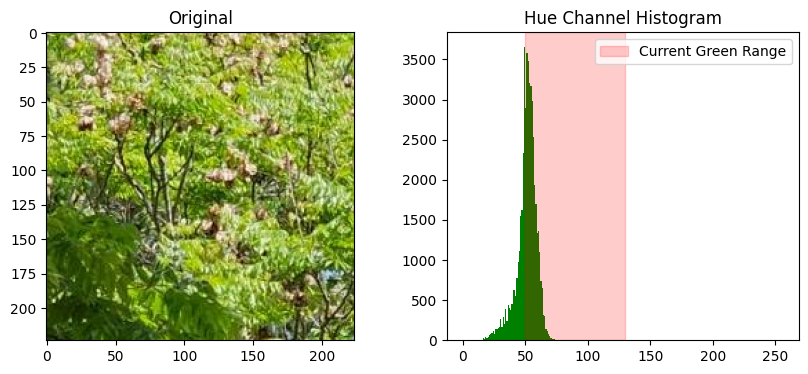

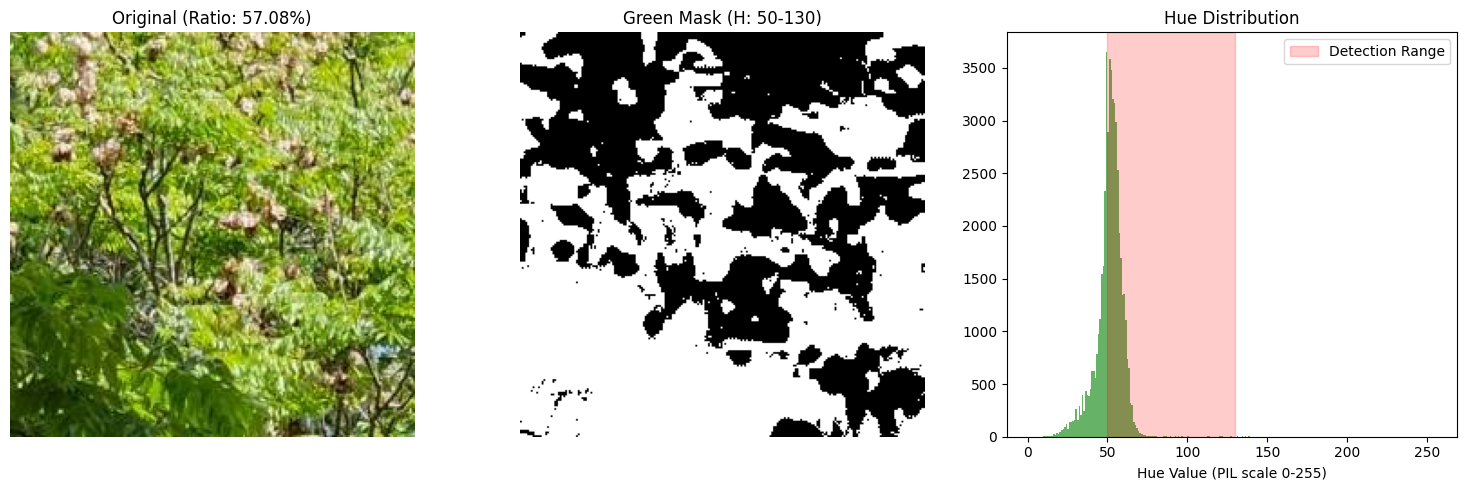

這張圖在目前的設定下，綠色佔比為: 0.5708
你的 threshold 是 0.1，所以判定為: 合格


In [17]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 抓一張你覺得「應該合格」但被判「不合格」的圖
test_patch = Image.open('/media/hlajungo/D/linux/repo_my/1142_nn/1142_nn_mid/data/process_cut/台灣欒樹/台灣欒樹_0002_2_2.jpg').convert('RGB')
hsv_test = np.array(test_patch.convert('HSV'))
h_channel = hsv_test[:, :, 0]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(test_patch)
plt.title("Original")

plt.subplot(1, 2, 2)
plt.hist(h_channel.ravel(), bins=256, range=(0, 256), color='green')
plt.title("Hue Channel Histogram")
plt.axvspan(50, 130, color='red', alpha=0.2, label='Current Green Range') # 顯示你目前的判定範圍
plt.legend()
plt.show()

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# 1. 讀取圖片 (請確保路徑正確)
img_path = '/media/hlajungo/D/linux/repo_my/1142_nn/1142_nn_mid/data/process_cut/台灣欒樹/台灣欒樹_0002_2_2.jpg'
test_patch = Image.open(img_path).convert('RGB')

# 2. 轉換到 HSV 並取得 Hue 通道
hsv_test = np.array(test_patch.convert('HSV'))
h_channel = hsv_test[:, :, 0]
s_channel = hsv_test[:, :, 1]
v_channel = hsv_test[:, :, 2]

# 3. 計算目前的綠色遮罩 (假設你用的是 50-130)
lower_h, upper_h = 50, 130
green_mask = (h_channel > lower_h) & (h_channel < upper_h) & (s_channel > 40) & (v_channel > 40)
actual_ratio = np.mean(green_mask)

# 4. 繪製視覺化結果
plt.figure(figsize=(15, 5))

# 子圖 1: 原圖
plt.subplot(1, 3, 1)
plt.imshow(test_patch)
plt.title(f"Original (Ratio: {actual_ratio:.2%})")
plt.axis('off')

# 子圖 2: 判定為「綠色」的區域 (白色代表合格像素)
plt.subplot(1, 3, 2)
plt.imshow(green_mask, cmap='gray')
plt.title(f"Green Mask (H: {lower_h}-{upper_h})")
plt.axis('off')

# 子圖 3: Hue 通道的分佈直方圖
plt.subplot(1, 3, 3)
plt.hist(h_channel.ravel(), bins=256, range=(0, 256), color='green', alpha=0.6)
plt.axvspan(lower_h, upper_h, color='red', alpha=0.2, label='Detection Range')
plt.title("Hue Distribution")
plt.xlabel("Hue Value (PIL scale 0-255)")
plt.legend()

plt.tight_layout()
plt.show()

print(f"這張圖在目前的設定下，綠色佔比為: {actual_ratio:.4f}")
print(f"你的 threshold 是 0.1，所以判定為: {'合格' if actual_ratio >= 0.1 else '不合格'}")